### **Project : Employee Attrition Analysis**
### **Algorithm : CART (Decision Tree Classifier)**

In [29]:
# Importing Required Libraries 

# Import numerical library 
import numpy as np

# Import Manipulation and Cleaning library
import pandas as pd 

# Import Plotting Library
import matplotlib.pyplot as plt 

# Import Advanced Library 
import seaborn as sns 

# Import Train Test Split 
from sklearn.model_selection import train_test_split

# Import Label Encoder 
from sklearn.preprocessing import LabelEncoder

# Import Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier

# Import evaluation metrics 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [30]:
# Load dataset 
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition-selected-columns.csv")

In [31]:
# Step No 3 : Data Understanding 

# Display first rows 
print(df.head())

# Display dataset shape 
print(df.shape)

# Display the dataset information 
print(df.info())

# Display Statistical summary 
print(df.describe())

   Age Attrition  ... EmployeeCount  EmployeeNumber
0   41       Yes  ...             1               1
1   49        No  ...             1               2
2   37       Yes  ...             1               4
3   33        No  ...             1               5
4   27        No  ...             1               7

[5 rows x 10 columns]
(1470, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1470 non-null   int64 
 1   Attrition         1470 non-null   object
 2   BusinessTravel    1470 non-null   object
 3   DailyRate         1470 non-null   int64 
 4   Department        1470 non-null   object
 5   DistanceFromHome  1470 non-null   int64 
 6   Education         1470 non-null   int64 
 7   EducationField    1470 non-null   object
 8   EmployeeCount     1470 non-null   int64 
 9   EmployeeNumber    1470 non-null   in

In [32]:
# Step No 4 : Cleaning dataset 

# Checking missing values in the dataset 
print(df.isnull().sum())

# Checking duplicated values 
print(df.duplicated().sum())

# Remove duplicated values 
df = df.drop_duplicates()

Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64
0


In [33]:
# Step No 5 : Encode Categorical Data 

# Crate Label Encoder Object 
encoder = LabelEncoder()

# Encode categorical columns
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

In [34]:
# Step No 6 : Features and Target 

# Define input features
X = df.drop(
    columns= ["Attrition"]
)

# Define target variable 
y = df["Attrition"]

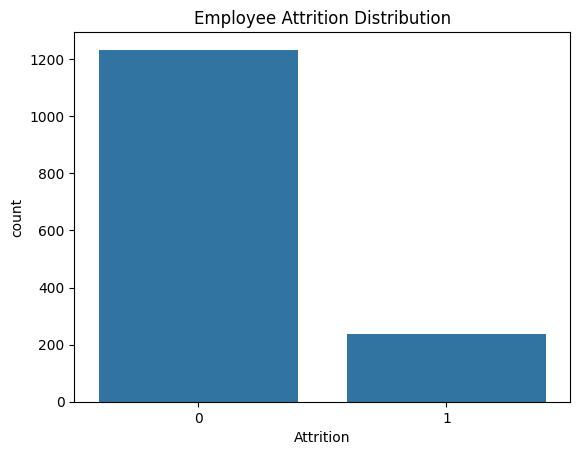

In [35]:
# Step No 7 : Visualization 

# Crate Countplot 
sns.countplot(x="Attrition" , data= df)

# Set Title
plt.title("Employee Attrition Distribution")

# Display Plot 
plt.show()

In [36]:
# Step No 8 : Train Test Split 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state=42)

In [37]:
# Step No 9 : Create Decision Tree Model 
# CART uses Gini Index for classification.
# It creates binary splits at each node.
# DecisionTreeClassifier with criterion='gini' imple0ments CART.

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

In [38]:
# Step No 10 :  Train Model 
model.fit(X_train , y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [39]:
# Step No 11 : Prediction 
y_pred = model.predict(X_test)

# Display the predicted values 
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


In [40]:
# Step No 12 : Evaluation metrics 

# Accuracy 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Classification Report 
print("Classification Report : ")
print(classification_report(y_test , y_pred))

# Confusion Matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred ))

Accuracy Score : 
0.8571428571428571
Classification Report : 
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       255
           1       0.38      0.13      0.19        39

    accuracy                           0.86       294
   macro avg       0.63      0.55      0.56       294
weighted avg       0.81      0.86      0.82       294

Confusion Matrix : 
[[247   8]
 [ 34   5]]


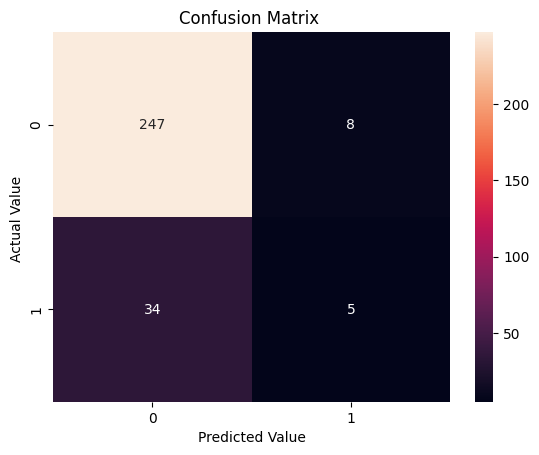

In [41]:
# Step No 13 : Confusion Matrix Visualization 
sns.heatmap(
    confusion_matrix(y_test , y_pred ),
    annot = True ,
    fmt = "d"
)

# Set Title 
plt.title("Confusion Matrix ")

# X label 
plt.xlabel("Predicted Value")

# Y label 
plt.ylabel("Actual Value ")

# Display Output 
plt.show()

In [42]:
# Step No 14 : Feature Importance 
feature_importance = pd.DataFrame({
    "Feature ": X.columns,
    "Importance": model.feature_importances_
})
print(feature_importance)

           Feature   Importance
0               Age    0.337440
1    BusinessTravel    0.013853
2         DailyRate    0.313149
3        Department    0.070258
4  DistanceFromHome    0.054543
5         Education    0.000000
6    EducationField    0.074493
7     EmployeeCount    0.000000
8    EmployeeNumber    0.136264


In [43]:
# Step No 15 : User Input 

print("\nEnter Employee Information\n")

# Prompt the age from user 
Age = int(input("Enter the Age : "))

# Prompt the Business Travel from the usr 
BusinessTravel = int(input("Enter Business Travel : "))

# Prompt the Daily Rate from the user 
DailyRate = float(input("Enter the Daily Rate : "))

# Prompt the Department from the user 
Department = int(input("Enter the Department : "))

# Prompt the Distance from the home 
DistanceFromHome = int(input("Enter the Distance from the Home : "))

# Prompt the Education 
Education = int(input("Enter the Education : "))

# Prompt the Education field 
EducationField = int(input("Enter the Education Field : "))

# Prompt the Employee Count 
EmployeeCount = int(input("Employee Count : "))

# Prompt the Employee Number 
EmployeeNumber = int(input("Enter Employee Number : "))


Enter Employee Information



In [44]:
# Step No 16 : Create User DataFrame 
user_data = pd.DataFrame({
    "Age": [Age], 
    "BusinessTravel":[BusinessTravel],
    "DailyRate":[DailyRate],
    "Department":[Department],
    "DistanceFromHome":[DistanceFromHome],
    "Education":[Education],
    "EducationField":[EducationField],
    "EmployeeCount":[EmployeeCount],
    "EmployeeNumber":[EmployeeNumber]
})

In [45]:
# Step No 17 : Final Prediction
result = model.predict(user_data)

In [46]:
# Step No 18 : Final Output 
if result[0] == 1 : 
    print(" Employee Likely To Leave. ")
else:
    print("Employee Likely To Stay ")

Employee Likely To Stay 
